# RAG Testing

#### The application reads data about MCP(Model Context protocol) server from internet,stores in Vector DB, chunk the data with embedding and useful to answer the question about MCP while inferenced

![RAG Testing](img/RagTesting.png)

In [1]:
!pip install -qU langchain langchain-ollama langchain-chroma langchain-community langchain-text-splitters


[notice] A new release of pip is available: 26.1.2 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


#### Important libraries to import before starting RAG based testing

In [2]:
from langchain_ollama import OllamaEmbeddings
from langchain_chroma import Chroma
from langchain_community.document_loaders import WebBaseLoader
from langchain_text_splitters import RecursiveCharacterTextSplitter
from typing import List
from langchain_core.prompts import ChatPromptTemplate
from langchain_core.output_parsers import StrOutputParser
from langchain_core.runnables import RunnablePassthrough
from langchain_core.documents import Document
from langchain_ollama import ChatOllama

C:\Users\md twasif hossain\AppData\Local\Temp\ipykernel_13424\2351560790.py:3: DeprecationWarning: `langchain-community` is being sunset and is no longer actively maintained. See https://github.com/langchain-ai/langchain-community/issues/674 for details and migration guidance toward standalone integration packages.
  from langchain_community.document_loaders import WebBaseLoader
USER_AGENT environment variable not set, consider setting it to identify your requests.


#### Setup the Ollama

In [3]:
llm = ChatOllama(
    base_url="http://localhost:11434", 
    model="llama3.2",
    temperature=0.5,
    max_tokens=512,
    )

#### Load data from web

In [4]:
loader = WebBaseLoader("https://www.descope.com/learn/post/mcp")
data = loader.load()

# Split the data into chunks
text_splitter = RecursiveCharacterTextSplitter(
    chunk_size=500,
    chunk_overlap=0,
    length_function=len
)
chunks = text_splitter.split_documents(data)

# Add texts to Chroma vector store/DB
embeddings = OllamaEmbeddings(model="nomic-embed-text", base_url="http://localhost:11434")
vectorDB = Chroma.from_documents(documents=chunks, embedding=embeddings)

# Create a retriever from the vector store
retriever = vectorDB.as_retriever(search_kwargs={"k": 2})

def format_docs(docs: List[Document]) -> str:
    return "\n\n".join([doc.page_content for doc in docs])

template = """You are a helpful assistant that answers questions based on the context provided.
{context}
Give a summary not a full detail
Question: {question}
Answer:"""

prompt = ChatPromptTemplate.from_template(template)

def retrieve_and_format(question: str) -> str:
    docs = retriever.invoke(question)
    return format_docs(docs)

chain = prompt | llm | StrOutputParser()


#### Output of the LLM question


In [5]:
question = "What is Relation between function calling and mcp?"
context = retrieve_and_format(question)
response = chain.invoke({"context": context, "question": question})
print(response)


The Model Context Protocol (MCP) is not mutually exclusive with function calling, but rather standardizes how function calling works, adding it to any AI application that implements the protocol, regardless of the underlying model vendor.


### Flow : Testing RAG application with Deepeval

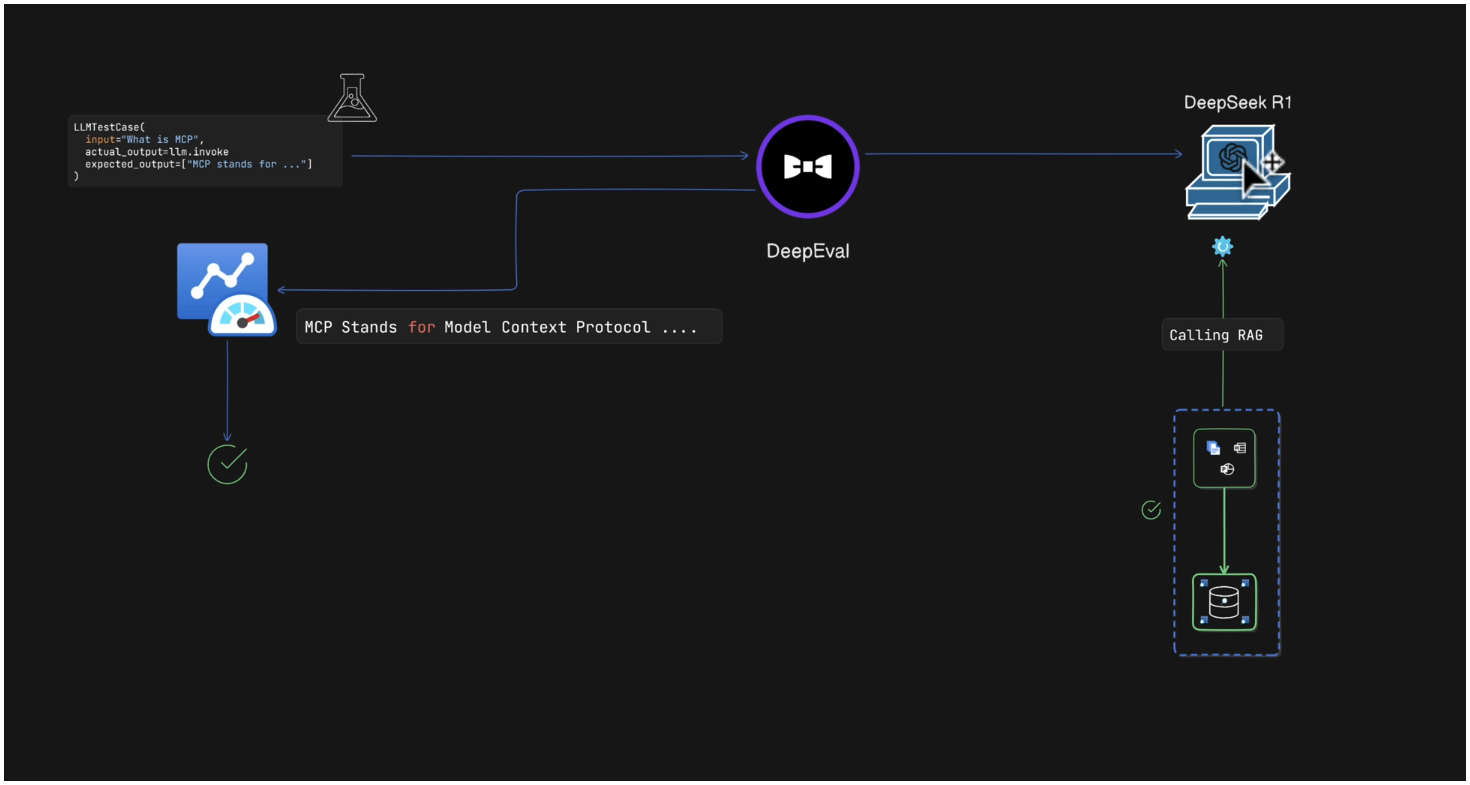

#### Setup Golden Dataset

In [17]:
test_data = [
    {
        "input": "What is MCP?",
        "expected_output": "The Model Context Protocol (MCP) addresses this challenge by providing a standardized way for LLMs to connect with external data sources and tools—essentially a “universal remote” for AI."
    },
    {
        "input": "What is Relation between function calling and mcp?",
        "expected_output": "Function calling is a feature that allows LLMs to interact with external tools and APIs, while MCP provides a standardized way for LLMs to connect with these external data sources and tools. Together, they enable LLMs to access and utilize external information effectively."
    },
    {
        "input": "What is the purpose of MCP?",
        "expected_output": "The purpose of MCP is to provide a standardized way for LLMs to connect with external data sources and tools, enabling them to access and utilize external information effectively."
    },
    {
        "input": "What are the core components of MCP, just give me headings?",
        "expected_output": "The core components of MCP are: 1) The MCP specification, 2) The MCP server, 3) The MCP client, and 4) The MCP protocol."
    }
]

In [18]:
from deepeval.models import OpenAIModel
from deepeval.test_case import LLMTestCase
from deepeval.metrics import AnswerRelevancyMetric
from deepeval.evaluate import evaluate
from deepeval.dataset import EvaluationDataset, Golden 

goldens_dataset_confident = []

for data in test_data:
    golden_dataset = Golden(
        input=data["input"],
        expected_output=data["expected_output"],
        context=[f"Context for: {data['input']}"]
    )
    goldens_dataset_confident.append(golden_dataset)

new_ConfidentAI_Dataset = EvaluationDataset(goldens=goldens_dataset_confident)
new_ConfidentAI_Dataset 

EvaluationDataset(test_cases=[], goldens=[Golden(id=None, input='What is MCP?', actual_output=None, expected_output='The Model Context Protocol (MCP) addresses this challenge by providing a standardized way for LLMs to connect with external data sources and tools—essentially a “universal remote” for AI.', context=['Context for: What is MCP?'], retrieval_context=None, additional_metadata=None, comments=None, tools_called=None, expected_tools=None, source_file=None, name=None, custom_column_key_values=None, multimodal=False, images_mapping=None), Golden(id=None, input='What is Relation between function calling and mcp?', actual_output=None, expected_output='Function calling is a feature that allows LLMs to interact with external tools and APIs, while MCP provides a standardized way for LLMs to connect with these external data sources and tools. Together, they enable LLMs to access and utilize external information effectively.', context=['Context for: What is Relation between function cal

#### Push the Dataset to Confident AI

In [20]:
from dotenv import load_dotenv
import os

load_dotenv(r"D:\Udemy_AI_project\Session1_Intro\.env")
os.environ.setdefault("CONFIDENT_API_KEY", os.getenv("CONFIDENT_API_KEY", ""))

# Note: do not print CONFIDENT_API_KEY (it is a secret)

'<CONFIDENT_API_KEY redacted>'

In [21]:
new_ConfidentAI_Dataset.push(alias="TestGoldenDatasetWithRAG")

✅ Dataset successfully pushed to Confident AI! View at 
]8;id=1260339;https://app.confident-ai.com/project/cmt850wvu0008lf0vjgk2dpvs/datasets/cmterx2d6002drn0t0eik1dib\https://app.confident-ai.com/project/cmt850wvu0008lf0vjgk2dpvs/datasets/cmterx2d6002drn0t0eik1dib]8;;\